In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

# Fixing all random seeds
SEED = 2025
np.random.seed(SEED)
random.seed(SEED)


nb_classes = 2
labels = ["Pas de Récidive", "Récidive"]
ticksx = np.arange(nb_classes) + 0.5
ticksy = np.arange(nb_classes) + 0.5

## utils 

In [2]:
def compute_metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")  # Use "weighted" for multiclass
    PPV = precision_score(y_test, y_pred, average="weighted")
    Sensitivity = recall_score(y_test, y_pred, average="weighted")
    return accuracy, balanced_accuracy, f1, PPV, Sensitivity


def getWrongPatients(yhat, ytrue, patients):
    if len(np.where(yhat != ytrue)) != 0:
        return patients[np.where(yhat != ytrue)]
    else:
        print("No Misclassified Patients.")
        return np.array([0])

## codes

In [3]:
patients_KB_to_eliminate = [23, 31, 54, 60, 68, 72, 76, 84, 86]
patients_R1_to_eliminate = [116, 117, 125, 134, 156, 180, 197, 198]
patients_NaN_to_eliminate = [
    18,
    70,
    114,
    116,
    119,
    212,
]  # 113, 124, 129, 138, 139, 143, 145, 155, 159]

patients_to_eliminate = [208, 231, 250] + list(
    set(patients_KB_to_eliminate + patients_R1_to_eliminate + patients_NaN_to_eliminate)
)
print(len(patients_to_eliminate), sorted(patients_to_eliminate))

df = pd.read_excel("../data/tabs/input_dataframe_prognosis.xlsx")
df = (
    df.loc[~df["patient"].isin(patients_to_eliminate)]
    .sort_values(by="patient")
    .drop("Nbre de lames", axis=1)
)

25 [18, 23, 31, 54, 60, 68, 70, 72, 76, 84, 86, 114, 116, 117, 119, 125, 134, 156, 180, 197, 198, 208, 212, 231, 250]


In [4]:
df_kb = df.loc[
    df["patient"].between(1, 110)
    | df["patient"].between(213, 222)
    | df["patient"].between(253, 260)
]
df_hm = df.loc[df["patient"].between(111, 160)]
df_bj = df.loc[df["patient"].between(161, 212) | df["patient"].between(223, 252)]

df_kb.shape, df_hm.shape, df_bj.shape

((111, 20), (43, 20), (67, 20))

In [5]:
df_kb["Récidive Globale"].value_counts()

Récidive Globale
1    57
0    54
Name: count, dtype: int64

In [6]:
df_hm["Récidive Globale"].value_counts()

Récidive Globale
1    23
0    20
Name: count, dtype: int64

In [7]:
df_bj["Récidive Globale"].value_counts()

Récidive Globale
0    41
1    26
Name: count, dtype: int64

In [8]:
cols_to_scale = [
    "Pattern expansif multinodulaire",
    "log1p_taille",
    "log1p_AFP",
    "%P",
    "%P_max",
    "NP_CntArea_norm",
    "P_CntArea_norm",
    "P_CntArea_norm_max",
    "Intra-tumoral",
    "Peri-tumoral",
    "density",
    "mean nucleus area",
    "anisocaryose",
    "nucleocyto index",
]

In [9]:
train = df_kb.loc[df_kb["patient"].between(1, 89)]
test = df_kb.loc[~df_kb["patient"].isin(train["patient"])]

robust_scaler = RobustScaler()
data_scaled = robust_scaler.fit_transform(train[cols_to_scale])
# Kremlin Bicetre
train[cols_to_scale] = data_scaled
data_scaled = robust_scaler.transform(test[cols_to_scale])
test[cols_to_scale] = data_scaled

# HenriMondor
data_scaled = robust_scaler.transform(df_hm[cols_to_scale])
df_hm_scaled = df_hm.copy()
df_hm_scaled[cols_to_scale] = data_scaled

# Beaujon
data_scaled = robust_scaler.transform(df_bj[cols_to_scale])
df_bj_scaled = df_bj.copy()
df_bj_scaled[cols_to_scale] = data_scaled

FINAL_COLS = cols_to_scale
X_train = train[FINAL_COLS]
y_train = train["Récidive Globale"]

X_test = test[FINAL_COLS]
y_test = test["Récidive Globale"]
patients_train = train["patient"]
patients_test = test["patient"]

X_hm = df_hm_scaled[FINAL_COLS]
y_hm = df_hm_scaled["Récidive Globale"]
patients_hm = df_hm_scaled["patient"]

X_bj = df_bj_scaled[FINAL_COLS]
y_bj = df_bj_scaled["Récidive Globale"]
patients_bj = df_bj_scaled["patient"]

In [10]:
models = {
    "SVM (kernel=rbf)": SVC(
        kernel="rbf", random_state=SEED, probability=True, C=1.5, gamma="scale"
    ),
}

In [11]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "F1-Score",
        "PPV",
        "Sensitivity",
    ]
)
results_hm = pd.DataFrame(columns=results.columns)
results_bj = pd.DataFrame(columns=results.columns)
results["Model"] = list(models.keys())
results_hm["Model"] = list(models.keys())
results_bj["Model"] = list(models.keys())

cm_results_hm = {}
cm_results_bj = {}
cm_results = {}
dict_models = {}
for name, model in models.items():
    print(f"Training {name}...", end="")
    model.fit(X_train, y_train)  # Train the model

    y_pred = model.predict(X_test)  # Predict on KB
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_test, y_pred)
    model_results = pd.DataFrame(
        {
            "Model": [name],
            "Accuracy": [accuracy],
            "Balanced Accuracy": [balanced_accuracy],
            "F1-Score": [f1],
            "PPV": [PPV],
            "Sensitivity": [Sensitivity],
        }
    )
    model_results = model_results.dropna(axis=1, how="all")
    results.loc[results["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]
    cm_results[name] = confusion_matrix(y_test, y_pred)

    y_pred_hm = model.predict(X_hm)  # Predict on HM
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_hm, y_pred_hm)
    results_hm.loc[results_hm["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]
    cm_results_hm[name] = confusion_matrix(y_hm, y_pred_hm)

    print(model.support_)

    y_pred_bj = model.predict(X_bj)  # Predict on BJ
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_bj, y_pred_bj)
    results_bj.loc[results_bj["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]
    cm_results_bj[name] = confusion_matrix(y_bj, y_pred_bj)
    print(" Done!")

    y_proba = model.predict_proba(X_test)[:, 1]
    y_proba_hm = model.predict_proba(X_hm)[:, 1]
    y_proba_bj = model.predict_proba(X_bj)[:, 1]
    dict_models[name] = [
        model,
        y_pred,
        y_pred_hm,
        y_pred_bj,
        y_proba,
        y_proba_hm,
        y_proba_bj,
    ]

    y_proba = model.predict_proba(X_test)[:, 1]
    y_proba_hm = model.predict_proba(X_hm)[:, 1]
    y_proba_bj = model.predict_proba(X_bj)[:, 1]
    dict_models[name] = [
        model,
        y_pred,
        y_pred_hm,
        y_pred_bj,
        y_proba,
        y_proba_hm,
        y_proba_bj,
    ]

Training SVM (kernel=rbf)...[ 0  1  3  5  6 10 11 13 17 20 21 22 26 27 28 33 34 37 38 40 43 47 53 55
 56 57 61 64 65 70 71 72  2  4  7  8  9 12 14 16 18 19 23 25 29 30 31 41
 45 46 48 49 50 51 52 54 58 59 60 62 63 66 67 68 69]
 Done!


In [12]:
results = results.sort_values(by="Accuracy", ascending=False)
results["hopital"] = "PB"

results_hm = results_hm.sort_values(by="Accuracy", ascending=False)
results_hm["hopital"] = "HM"

results_bj = results_bj.sort_values(by="Accuracy", ascending=False)
results_bj["hopital"] = "BJ"

ALL_res = pd.concat([results, results_hm])
ALL_res = pd.concat([ALL_res, results_bj])
ALL_res

,Model,Accuracy,Balanced Accuracy,F1-Score,PPV,Sensitivity,hopital
0,SVM (kernel=rbf),0.921053,0.919444,0.920888,0.922011,0.921053,PB
0,SVM (kernel=rbf),0.906977,0.903261,0.906467,0.909974,0.906977,HM
0,SVM (kernel=rbf),0.910448,0.905722,0.910448,0.910448,0.910448,BJ


In [13]:
print("misclassified patients:")
for m in results["Model"]:
    wrong_patients = getWrongPatients(
        dict_models[m][1], y_test.squeeze(), np.array(patients_test)
    )
    liste = list(set(wrong_patients))
    liste.sort()
    print("   {:10s} on PB:".format(m), liste)

for m in results_hm["Model"]:
    wrong_patients = getWrongPatients(
        dict_models[m][2], y_hm.squeeze(), np.array(patients_hm)
    )
    liste = list(set(wrong_patients))
    liste.sort()
    print("   {:10s} on HM:".format(m), liste)

for m in results_bj["Model"]:
    wrong_patients = getWrongPatients(
        dict_models[m][3], y_bj.squeeze(), np.array(patients_bj)
    )
    liste = list(set(wrong_patients))
    liste.sort()
    print("   {:10s} on BJ:".format(m), liste)

misclassified patients:
   SVM (kernel=rbf) on PB: [217, 222, 257]
   SVM (kernel=rbf) on HM: [113, 131, 132, 138]
   SVM (kernel=rbf) on BJ: [162, 168, 181, 185, 244, 248]


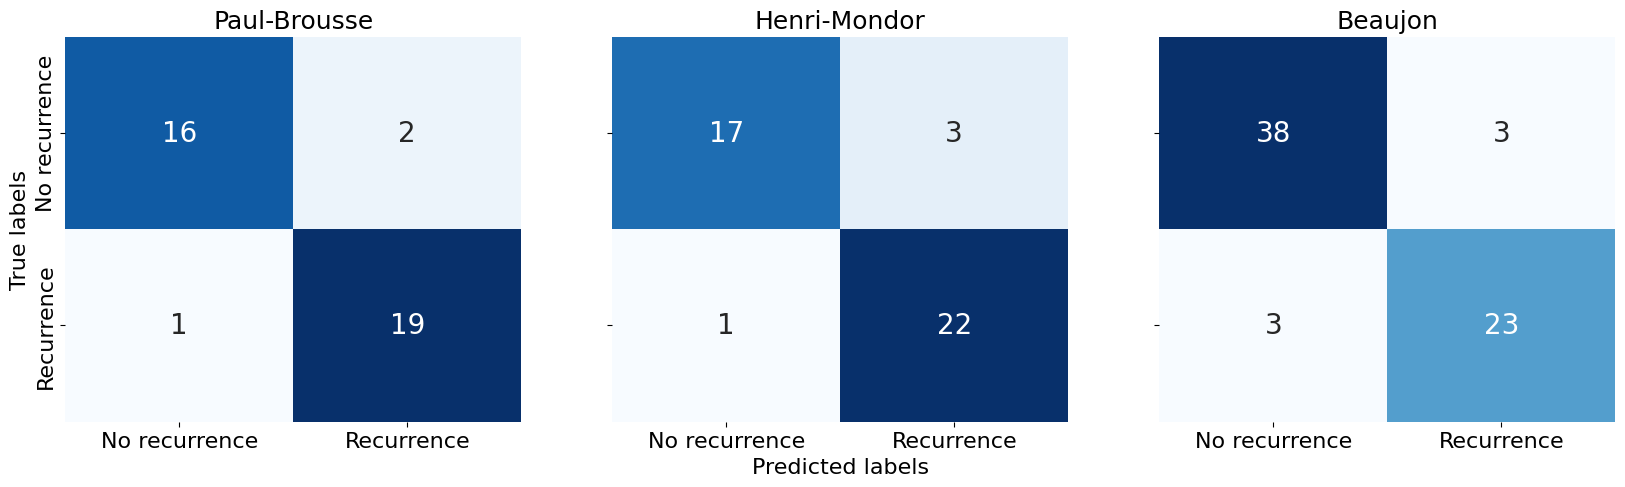

In [14]:
cm1 = cm_results["SVM (kernel=rbf)"]
cm2 = cm_results_hm["SVM (kernel=rbf)"]
cm3 = cm_results_bj["SVM (kernel=rbf)"]

cm_results = {"Paul-Brousse": cm1, "Henri-Mondor": cm2, "Beaujon": cm3}
labels = ["No recurrence", "Recurrence"]
rows, cols = 1, 3
fig, axes = plt.subplots(rows, cols, figsize=(20, 5), sharex=True, sharey=True)
axes = axes.flatten()
for idx, (model_name, cm) in enumerate(cm_results.items()):
    if idx >= rows * cols:
        break  # Stop if there are more models than grid cells

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 20},
    )
    axes[idx].set_title(f"{model_name}", fontsize=18)
    axes[1].set_xlabel("Predicted labels", fontsize=16)
    axes[0].set_ylabel("True labels", fontsize=16)
    axes[idx].tick_params(axis="x", labelsize=16)
    axes[idx].tick_params(axis="y", labelsize=16)
for i in range(len(cm_results), rows * cols):
    fig.delaxes(axes[i])
plt.show()

## Calibration analysis

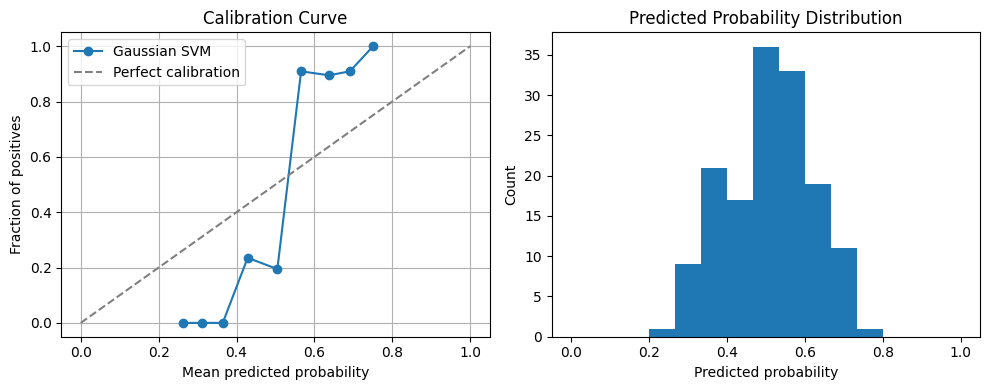

In [15]:
svm_model = models["SVM (kernel=rbf)"]
y_proba = svm_model.predict_proba(X_test)[:, 1]
y_pred = svm_model.predict(X_test)
y_proba_hm = svm_model.predict_proba(X_hm)[:, 1]
y_pred_hm = svm_model.predict(X_hm)
y_proba_bj = svm_model.predict_proba(X_bj)[:, 1]
y_pred_bj = svm_model.predict(X_bj)

PROBA = np.concatenate((y_proba, y_proba_hm, y_proba_bj), axis=None)
PREDS = np.concatenate((y_pred, y_pred_hm, y_pred_bj), axis=None)
TRUE = np.concatenate((y_test, y_hm, y_bj))

bins = 15
fraction_of_positives, mean_predicted_value = calibration_curve(
    TRUE, PROBA, n_bins=bins, strategy="uniform"
)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4), sharex=True)
ax[0].plot(mean_predicted_value, fraction_of_positives, "o-", label="Gaussian SVM")
ax[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax[0].set_xlabel("Mean predicted probability")
ax[0].set_ylabel("Fraction of positives")
ax[0].set_title("Calibration Curve")
ax[0].legend()
ax[0].grid(True)

ax[1].hist(PROBA, bins=bins, range=(0, 1))
ax[1].set_xlabel("Predicted probability")
ax[1].set_ylabel("Count")
ax[1].set_title("Predicted Probability Distribution")
plt.tight_layout()
plt.savefig(f"Calibration Curve PB+HM+BJ (bins={bins}).jpg")
plt.show()

## 5-folds cross validation

In [16]:
X = df_kb[["patient"] + FINAL_COLS]
y = df_kb[["patient", "Récidive Globale"]]
patients = df_kb["patient"].values

In [17]:
from sklearn.pipeline import make_pipeline
scores, f1s = [], []
cm_results = []
n_splits = 5
sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=len(X)//5)
for split_id, (train_idx, test_idx) in enumerate(
    sss.split(X, df_kb["Récidive Globale"].values), 1
):
    print("Split", split_id)
    model = make_pipeline(RobustScaler(),SVC(kernel="rbf", C=1.5, gamma="scale"))
    train_patients = sorted(patients[train_idx])
    test_patients = sorted(patients[test_idx])
    print(f"\ttrain_ptients:", len(train_patients), train_patients)
    print(f"\ttest_ptients:", len(test_patients), test_patients)

    X_train, X_test = (
        X.loc[X["patient"].isin(train_patients)][FINAL_COLS],
        X.loc[X["patient"].isin(test_patients)][FINAL_COLS],
    )
    y_train, y_test = (
        y.loc[y["patient"].isin(train_patients)]["Récidive Globale"].values,
        y.loc[y["patient"].isin(test_patients)]["Récidive Globale"].values,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    scores.append(acc)
    f1s.append(f1)
    cm_results.append(confusion_matrix(y_test, y_pred))
    print(f"\taccuracy = {acc:.3f}, f1-score = {f1:.3f}")

Split 1
	train_ptients: 89 [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 16, 17, 19, 20, 21, 26, 28, 29, 30, 32, 33, 34, 35, 36, 38, 40, 42, 43, 45, 46, 49, 50, 51, 52, 55, 56, 57, 62, 63, 64, 65, 66, 67, 69, 71, 73, 77, 78, 79, 81, 82, 83, 85, 87, 88, 89, 90, 91, 92, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 213, 214, 215, 216, 217, 218, 220, 222, 253, 254, 255, 258, 260]
	test_ptients: 22 [6, 22, 24, 25, 27, 37, 41, 44, 47, 48, 53, 58, 61, 75, 80, 93, 94, 107, 219, 221, 257, 259]
	accuracy = 0.727, f1-score = 0.727
Split 2
	train_ptients: 89 [2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 17, 19, 20, 21, 22, 24, 25, 32, 33, 34, 35, 36, 37, 40, 41, 42, 46, 47, 48, 49, 50, 53, 55, 56, 57, 58, 61, 63, 64, 65, 66, 67, 69, 71, 73, 75, 77, 78, 79, 80, 81, 82, 85, 87, 88, 89, 90, 91, 92, 93, 95, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 213, 215, 216, 217, 218, 219, 220, 221, 222, 253, 254, 255, 257, 258]
	test_ptients: 22 [1, 7, 16, 26, 27, 28, 29, 30, 38, 

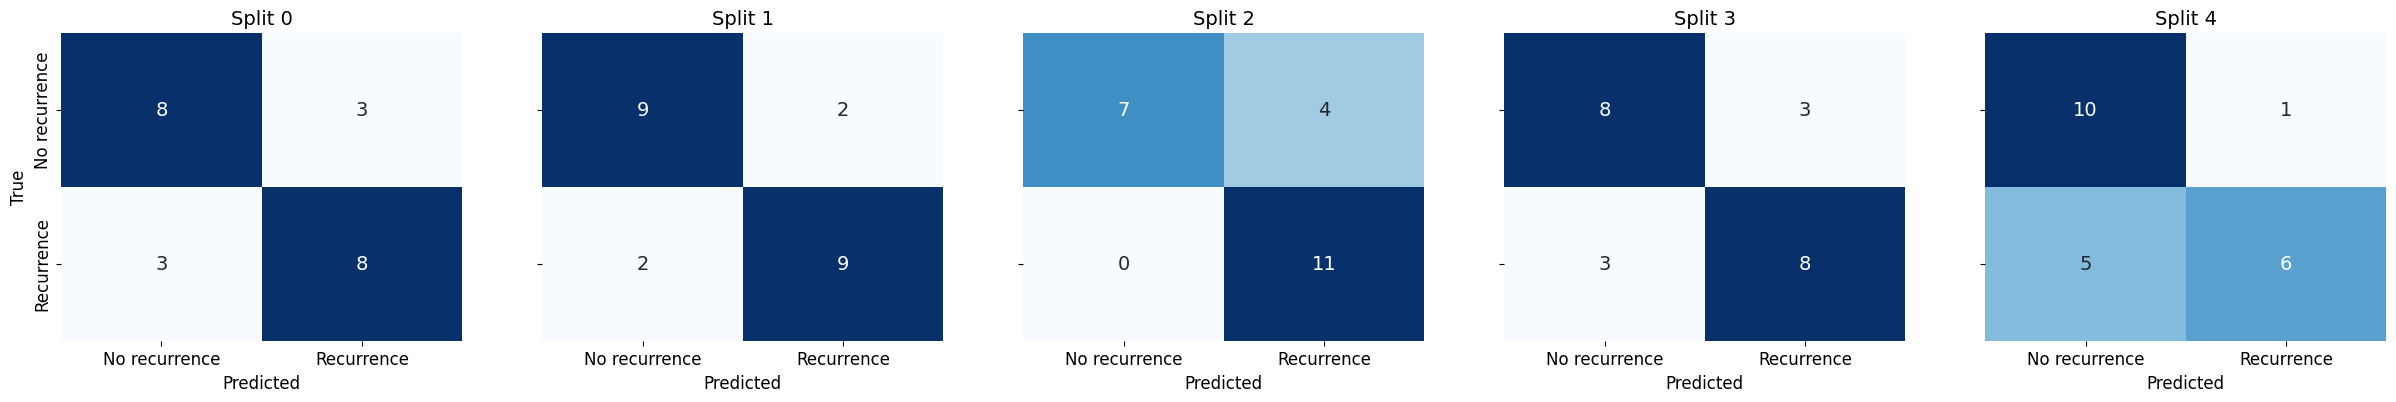

In [18]:
rows, cols = 1, n_splits
fig, axes = plt.subplots(rows, cols, figsize=(30, 4), sharex=True, sharey=True)
axes = axes.flatten()
for idx, cm in enumerate(cm_results):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14},
    )
    axes[idx].set_title(f"Split {idx}", fontsize=14)
    axes[idx].set_xlabel("Predicted", fontsize=12)
    axes[0].set_ylabel("True", fontsize=12)
    axes[idx].tick_params(axis="x", labelsize=12)
    axes[idx].tick_params(axis="y", labelsize=12)
for i in range(len(cm_results), rows * cols):
    fig.delaxes(axes[i])
plt.savefig("cross val matrices.jpg")
plt.show()

In [19]:
print(f"Mean: acc={np.mean(scores):.3f}, f1-score={np.mean(f1s):.3f}")
print(f"Std: acc={np.std(scores):.3f}, f1-score={np.std(f1s):.3f}")

Mean: acc=0.764, f1-score=0.757
Std: acc=0.045, f1-score=0.066


In [20]:
import pickle

# select only the models with good performances on the validation set 
scores, f1s = [], []
cm_results = []
is_done_selection = False
n_splits_taken=0
test_lists = []
good_test_list = []
model_list = []

patients_0 =  df_kb.loc[df_kb["Récidive Globale"] == 0]["patient"].values
patients_1 = df_kb.loc[df_kb["Récidive Globale"] == 1]["patient"].values

while not(is_done_selection):
    # init model
    model = make_pipeline(RobustScaler(),SVC(kernel="rbf", C=1.5, gamma="scale"))
    # split between train and val
    train_patients_0,test_patients_0 = train_test_split(patients_0,train_size=(len(patients)-35)//2)
    train_patients_1,test_patients_1 = train_test_split(patients_1,train_size=(len(patients)-35)//2)
    train_patients = np.concatenate([train_patients_0,train_patients_1])
    test_patients = np.concatenate([test_patients_0, test_patients_1])

    # not doing the same split twice
    if not(sorted(test_patients) in test_lists):
        test_lists.append(sorted(test_patients))

        X_train, X_test = (
            X.loc[X["patient"].isin(train_patients)][FINAL_COLS],
            X.loc[X["patient"].isin(test_patients)][FINAL_COLS],
        )
        y_train, y_test = (
            y.loc[y["patient"].isin(train_patients)]["Récidive Globale"].values,
            y.loc[y["patient"].isin(test_patients)]["Récidive Globale"].values,
        )

        # fit model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # compute metrics
        acc = accuracy_score(y_test, y_pred)
        if acc>0.9:
            n_splits_taken +=1
            model_list.append(model)
            f1 = f1_score(y_test, y_pred)
            scores.append(acc)
            f1s.append(f1)
            cm_results.append(confusion_matrix(y_test, y_pred))
            
            print(f"\ttrain_ptients:", len(train_patients), train_patients)
            print(f"\ttest_ptients:", len(test_patients), test_patients)
            print(f"\taccuracy = {acc:.3f}, f1-score = {f1:.3f}")
            # save model
            with open(f"../results/models/svm_{n_splits_taken}.pkl","wb") as f:
                pickle.dump(model,f)

            if n_splits_taken==n_splits:
                is_done_selection =True

	train_ptients: 76 [ 63  27  44   1  46 222 213  34 216  97 217  41  66  33 221  75  80 108
  79  45  87  50   2  32  26  51 259  21 254  93  12 104  65  95  38 218
   7  88  20  17  35  56  53  13  90  64  57  85 255  94 110  62  52  71
  92 260 107 214  77   8 257  37   9  10 103  49  43  36  42  78  30 105
  83 220  73  98]
	test_ptients: 35 [ 89  11  96 102  47 101   4  91  16  25  55   6  67  19  40 106   5  82
  28 109 215  61 100  81  24  29  48  58 253  69   3  22  99 219 258]
	accuracy = 0.914, f1-score = 0.923
	train_ptients: 76 [ 16  89  96  55  47  63  11  34  12  21 106   7 221  67   4  97 222 259
  91  38 218  32 102  40  65  95 254  66   1 101  51 217  44 213  79  75
   6  45  78 219  82  53  13 105  98  81  10 255  57   8  56 214 110   9
  62  24 100  83 260 215  42 103 258  58 257  90  52  37 107  30   5  61
  17  48  36  35]
	test_ptients: 35 [ 50  33 108  46 216  27  25   2  19  87  80  93 104  88  41  26  28  64
  49   3  29  99 253  69  94 220  43  20  92  85 109  

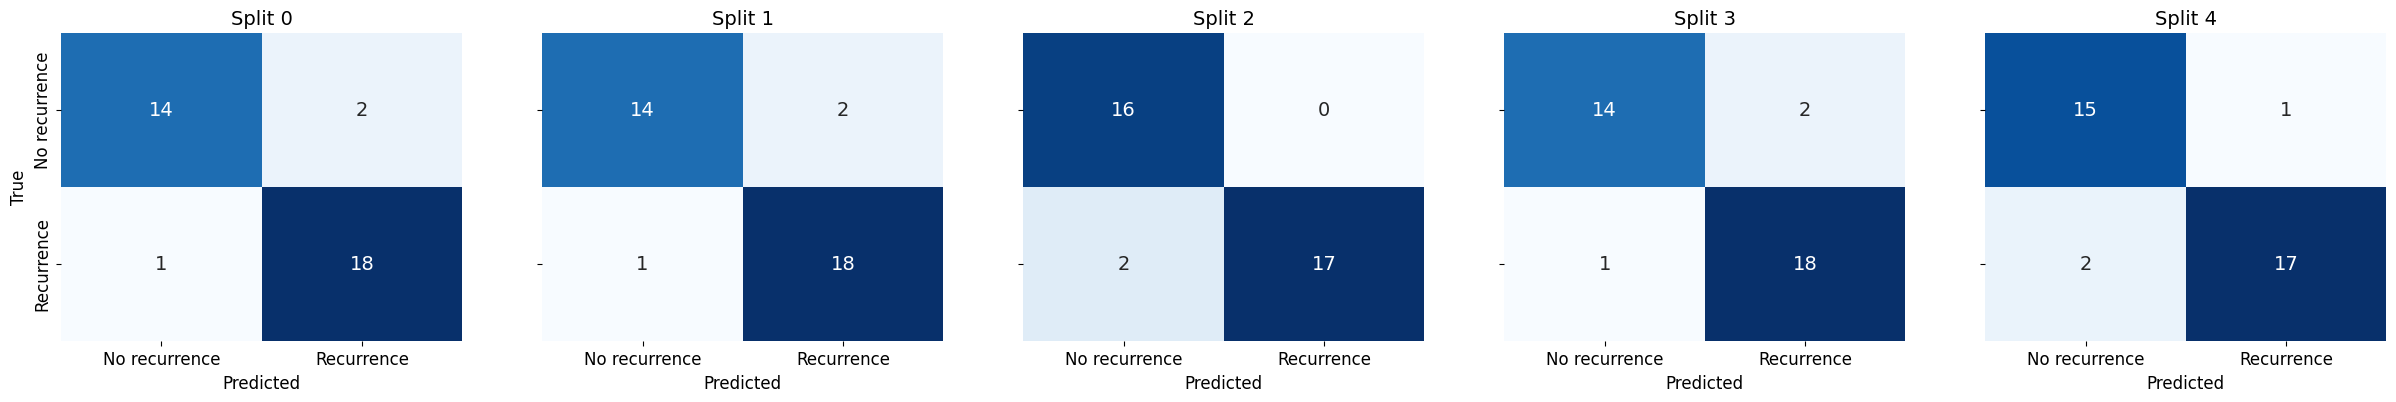

Mean: acc=0.920, f1-score=0.927
Std: acc=0.011, f1-score=0.009


In [21]:
rows, cols = 1, n_splits
fig, axes = plt.subplots(rows, cols, figsize=(30, 4), sharex=True, sharey=True)
axes = axes.flatten()
for idx, cm in enumerate(cm_results):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14},
    )
    axes[idx].set_title(f"Split {idx}", fontsize=14)
    axes[idx].set_xlabel("Predicted", fontsize=12)
    axes[0].set_ylabel("True", fontsize=12)
    axes[idx].tick_params(axis="x", labelsize=12)
    axes[idx].tick_params(axis="y", labelsize=12)
for i in range(len(cm_results), rows * cols):
    fig.delaxes(axes[i])
plt.savefig("cross val matrices.jpg")
plt.show()
print(f"Mean: acc={np.mean(scores):.3f}, f1-score={np.mean(f1s):.3f}")
print(f"Std: acc={np.std(scores):.3f}, f1-score={np.std(f1s):.3f}")

In [22]:
X_hm = df_hm[FINAL_COLS]
y_hm = df_hm["Récidive Globale"]

X_bj = df_bj[FINAL_COLS]
y_bj = df_bj["Récidive Globale"]

accs_hm,f1s_hm, = [],[]
accs_bj,f1s_bj, = [],[]

for i in range(n_splits):
    # load model
    with open(f"../results/models/svm_{i+1}.pkl","rb") as f:
        model = pickle.load(f)

    # eval on test set
    y_pred_hm = model.predict(X_hm)  # Predict on HM
    accuracy_hm, balanced_accuracy_hm, f1_hm, PPV_hm, Sensitivity_hm = compute_metrics(y_hm, y_pred_hm)
    print(f"results HM : {accuracy_hm, balanced_accuracy_hm, f1_hm, PPV_hm, Sensitivity_hm}")
    accs_hm.append(accuracy_hm)
    f1s_hm.append(f1_hm)

    y_pred_bj = model.predict(X_bj)  # Predict on BJ
    accuracy_bj, balanced_accuracy_bj, f1_bj, PPV_bj, Sensitivity_bj = compute_metrics(y_bj, y_pred_bj)

    print(f"results BJ : {accuracy_bj, balanced_accuracy_bj, f1_bj, PPV_bj, Sensitivity_bj}")
    accs_bj.append(accuracy_bj)
    f1s_bj.append(f1_bj)

print(f"mean acc = {np.mean(accs_hm)} (HM), {np.mean(accs_bj)} (BJ)")
print(f"std acc = {np.std(accs_hm)} (HM), {np.std(accs_bj)} (BJ)")
print(f"mean F1 = {np.mean(f1s_hm)} (HM), {np.mean(f1s_bj)} (BJ)")
print(f"std F1 = {np.std(f1s_hm)} (HM), {np.std(f1s_bj)} (BJ)")

results HM : (0.8837209302325582, 0.8815217391304347, 0.883467184308352, 0.8841799265605874, 0.8837209302325582)
results BJ : (0.8656716417910447, 0.8621013133208255, 0.8661097030570418, 0.8669430624654505, 0.8656716417910447)
results HM : (0.7441860465116279, 0.7445652173913043, 0.7444633516102601, 0.7455451525218967, 0.7441860465116279)
results BJ : (0.8208955223880597, 0.8395872420262664, 0.8231544977813634, 0.8487775028600315, 0.8208955223880597)
results HM : (0.8604651162790697, 0.8532608695652174, 0.8582945736434109, 0.8718776916451335, 0.8604651162790697)
results BJ : (0.7910447761194029, 0.8151969981238274, 0.7933852244155567, 0.8311667469106082, 0.7910447761194029)
results HM : (0.7906976744186046, 0.7782608695652173, 0.7823207946068851, 0.8215861657722122, 0.7906976744186046)
results BJ : (0.7910447761194029, 0.8222326454033771, 0.792723880597015, 0.8461413440962159, 0.7910447761194029)
results HM : (0.8372093023255814, 0.8282608695652174, 0.833561331509348, 0.85437430786268,

## full training

In [23]:
df_kb = df.loc[
    df["patient"].between(1, 110)
    | df["patient"].between(213, 222)
    | df["patient"].between(253, 260)
]
df_hm = df.loc[df["patient"].between(111, 160)]
df_bj = df.loc[df["patient"].between(161, 212) | df["patient"].between(223, 252)]

df_kb.shape, df_hm.shape, df_bj.shape

((111, 20), (43, 20), (67, 20))

In [24]:
train = df_kb

robust_scaler = RobustScaler()
data_scaled = robust_scaler.fit_transform(train[cols_to_scale])
# Kremlin Bicetre
train[cols_to_scale] = data_scaled

# HenriMondor
data_scaled = robust_scaler.transform(df_hm[cols_to_scale])
df_hm[cols_to_scale] = data_scaled

# Beaujon
data_scaled = robust_scaler.transform(df_bj[cols_to_scale])
df_bj[cols_to_scale] = data_scaled

FINAL_COLS = cols_to_scale
X_train = train[FINAL_COLS]
y_train = train["Récidive Globale"]

patients_train = train["patient"]

X_hm = df_hm[FINAL_COLS]
y_hm = df_hm["Récidive Globale"]
patients_hm = df_hm["patient"]

X_bj = df_bj[FINAL_COLS]
y_bj = df_bj["Récidive Globale"]
patients_bj = df_bj["patient"]

In [25]:
models = {
    "SVM (kernel=rbf)": SVC(
        kernel="rbf", random_state=SEED, probability=True, C=1.5, gamma="scale"
    ),
}

In [26]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "F1-Score",
        "PPV",
        "Sensitivity",
    ]
)
results_hm = pd.DataFrame(columns=results.columns)
results_bj = pd.DataFrame(columns=results.columns)
results_pb = pd.DataFrame(columns=results.columns)
results_pb["Model"] = list(models.keys())
results["Model"] = list(models.keys())
results_hm["Model"] = list(models.keys())
results_bj["Model"] = list(models.keys())

cm_results_hm = {}
cm_results_bj = {}
cm_results_pb = {}
cm_results = {}
dict_models = {}
for name, model in models.items():
    print(f"Training {name}...", end="")
    model.fit(X_train, y_train)  # Train the model

    y_pred = model.predict(X_train)  # Predict on KB
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_train, y_pred)
    results_pb.loc[results_pb["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]

    y_pred_hm = model.predict(X_hm)  # Predict on HM
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_hm, y_pred_hm)
    results_hm.loc[results_hm["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]
    cm_results_hm[name] = confusion_matrix(y_hm, y_pred_hm)

    y_pred_bj = model.predict(X_bj)  # Predict on BJ
    accuracy, balanced_accuracy, f1, PPV, Sensitivity = compute_metrics(y_bj, y_pred_bj)
    results_bj.loc[results_bj["Model"] == name] = [
        name,
        accuracy,
        balanced_accuracy,
        f1,
        PPV,
        Sensitivity,
    ]
    cm_results_bj[name] = confusion_matrix(y_bj, y_pred_bj)
    print(" Done!")

    y_proba_hm = model.predict_proba(X_hm)[:, 1]
    y_proba_bj = model.predict_proba(X_bj)[:, 1]
    dict_models[name] = [
        model,
        y_pred,
        y_pred_hm,
        y_pred_bj,
        y_proba,
        y_proba_hm,
        y_proba_bj,
    ]

    y_proba_hm = model.predict_proba(X_hm)[:, 1]
    y_proba_bj = model.predict_proba(X_bj)[:, 1]
    dict_models[name] = [
        model,
        y_pred,
        y_pred_hm,
        y_pred_bj,
        y_proba,
        y_proba_hm,
        y_proba_bj,
    ]

Training SVM (kernel=rbf)... Done!


In [27]:
results_pb = results_pb.sort_values(by="Accuracy", ascending=False)
results_pb["hopital"] = "PB train"

results_hm = results_hm.sort_values(by="Accuracy", ascending=False)
results_hm["hopital"] = "HM"

results_bj = results_bj.sort_values(by="Accuracy", ascending=False)
results_bj["hopital"] = "BJ"

ALL_res = pd.concat([results_pb, results_hm])
ALL_res = pd.concat([ALL_res, results_bj])
ALL_res 

,Model,Accuracy,Balanced Accuracy,F1-Score,PPV,Sensitivity,hopital
0,SVM (kernel=rbf),0.882883,0.882554,0.882845,0.88295,0.882883,PB train
0,SVM (kernel=rbf),0.837209,0.828261,0.833561,0.854374,0.837209,HM
0,SVM (kernel=rbf),0.80597,0.827392,0.808323,0.839792,0.80597,BJ
